# Data Exploration

### This notebook will contain the procedure followed for Data Exploration , Data Collection , Data Preprocessing . 

#### Initially we are using Flickr30K Dataset. WE are using a light weight dataset initially to completely set the pipeline for the model . 

##### A new benchmark collection for sentence-based image description and search, consisting of 30,000 images that are each paired with five different captions which provide clear descriptions of the salient entities and events. … The images were chosen from six different Flickr groups, and tend not to contain any well-known people or locations, but were manually selected to depict a variety of scenes and situations

In [10]:
# Importing all the Necessary Libraries
from pathlib import Path
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [11]:
# Importing Dataset using Kaggle 

data_dir = (Path.cwd().parent / "src" / "data").resolve()
data_dir.mkdir(parents=True, exist_ok=True)

path = kagglehub.dataset_download(
    "adityajn105/flickr30k",
    output_dir=str(data_dir)
)

print(path)

D:\agentic_project\src\data


In [12]:
BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR/"src"/"data"
IMAGES_DIR = DATA_DIR/"Images"
CAPTIONS_FILE = DATA_DIR/"captions.txt"

df = pd.read_csv(CAPTIONS_FILE)
df["image_path"] = df["image"].apply(lambda x: IMAGES_DIR/x)

print(df.shape)

df.head()

(158915, 3)


,image,caption,image_path
0,1000092795.jpg,Two young guys with shaggy hair look at their...,d:\agentic_project\src\data\Images\1000092795.jpg
1,1000092795.jpg,"Two young , White males are outside near many...",d:\agentic_project\src\data\Images\1000092795.jpg
2,1000092795.jpg,Two men in green shirts are standing in a yard .,d:\agentic_project\src\data\Images\1000092795.jpg
3,1000092795.jpg,A man in a blue shirt standing in a garden .,d:\agentic_project\src\data\Images\1000092795.jpg
4,1000092795.jpg,Two friends enjoy time spent together .,d:\agentic_project\src\data\Images\1000092795.jpg


In [13]:
print("Unique Images : ", df["image"].nunique())

print("Total Captions : ", len(df))

Unique Images :  31783
Total Captions :  158915


#### The dataset Size clearly states that there are more than 30K images and more than 150K Captions . which is roughly 5 captions per image .

In [14]:
print("Missing image files : ", (~df["image_path"].apply(lambda p : p.exists())).sum())

Missing image files :  0


In [15]:
df.groupby("image").size().describe()

count    31783.0
mean         5.0
std          0.0
min          5.0
25%          5.0
50%          5.0
75%          5.0
max          5.0
dtype: float64

Thus the above description clerly shows that every image has exactly 5 caption . 

## Now lets visualize the images

In [16]:
def show_image_with_captions(image_name):
    rows = df[df["image"] == image_name]
    img = Image.open(rows.iloc[0]["image_path"])

    plt.figure(figsize=(8,6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(image_name)
    plt.show()

    for i, caption in enumerate(rows["caption"].tolist(), 1):
        print(f"{i}. {caption}")



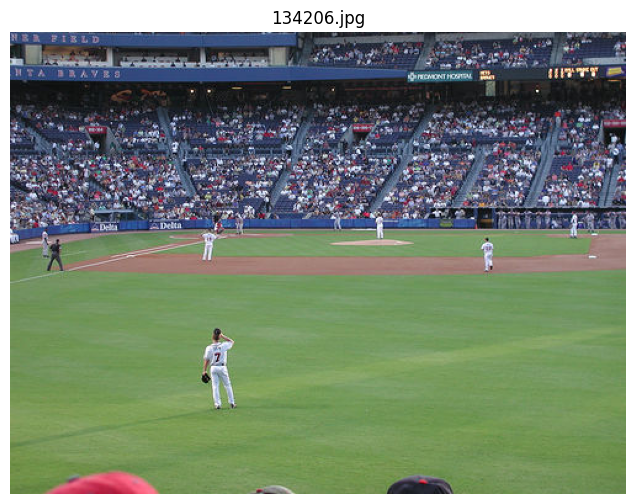

1.  The players of the baseball team are standing on the field , with many people watching from the stands .
2.  Baseball players are playing on a field in a stadium filled with people .
3.  A team plays baseball at a large crowded stadium .
4.  A crowd cheers on a baseball team .
5.  game is playing in the stadium


In [17]:
show_image_with_captions("134206.jpg")

#### Now lets, Randomly visualize the Dataset

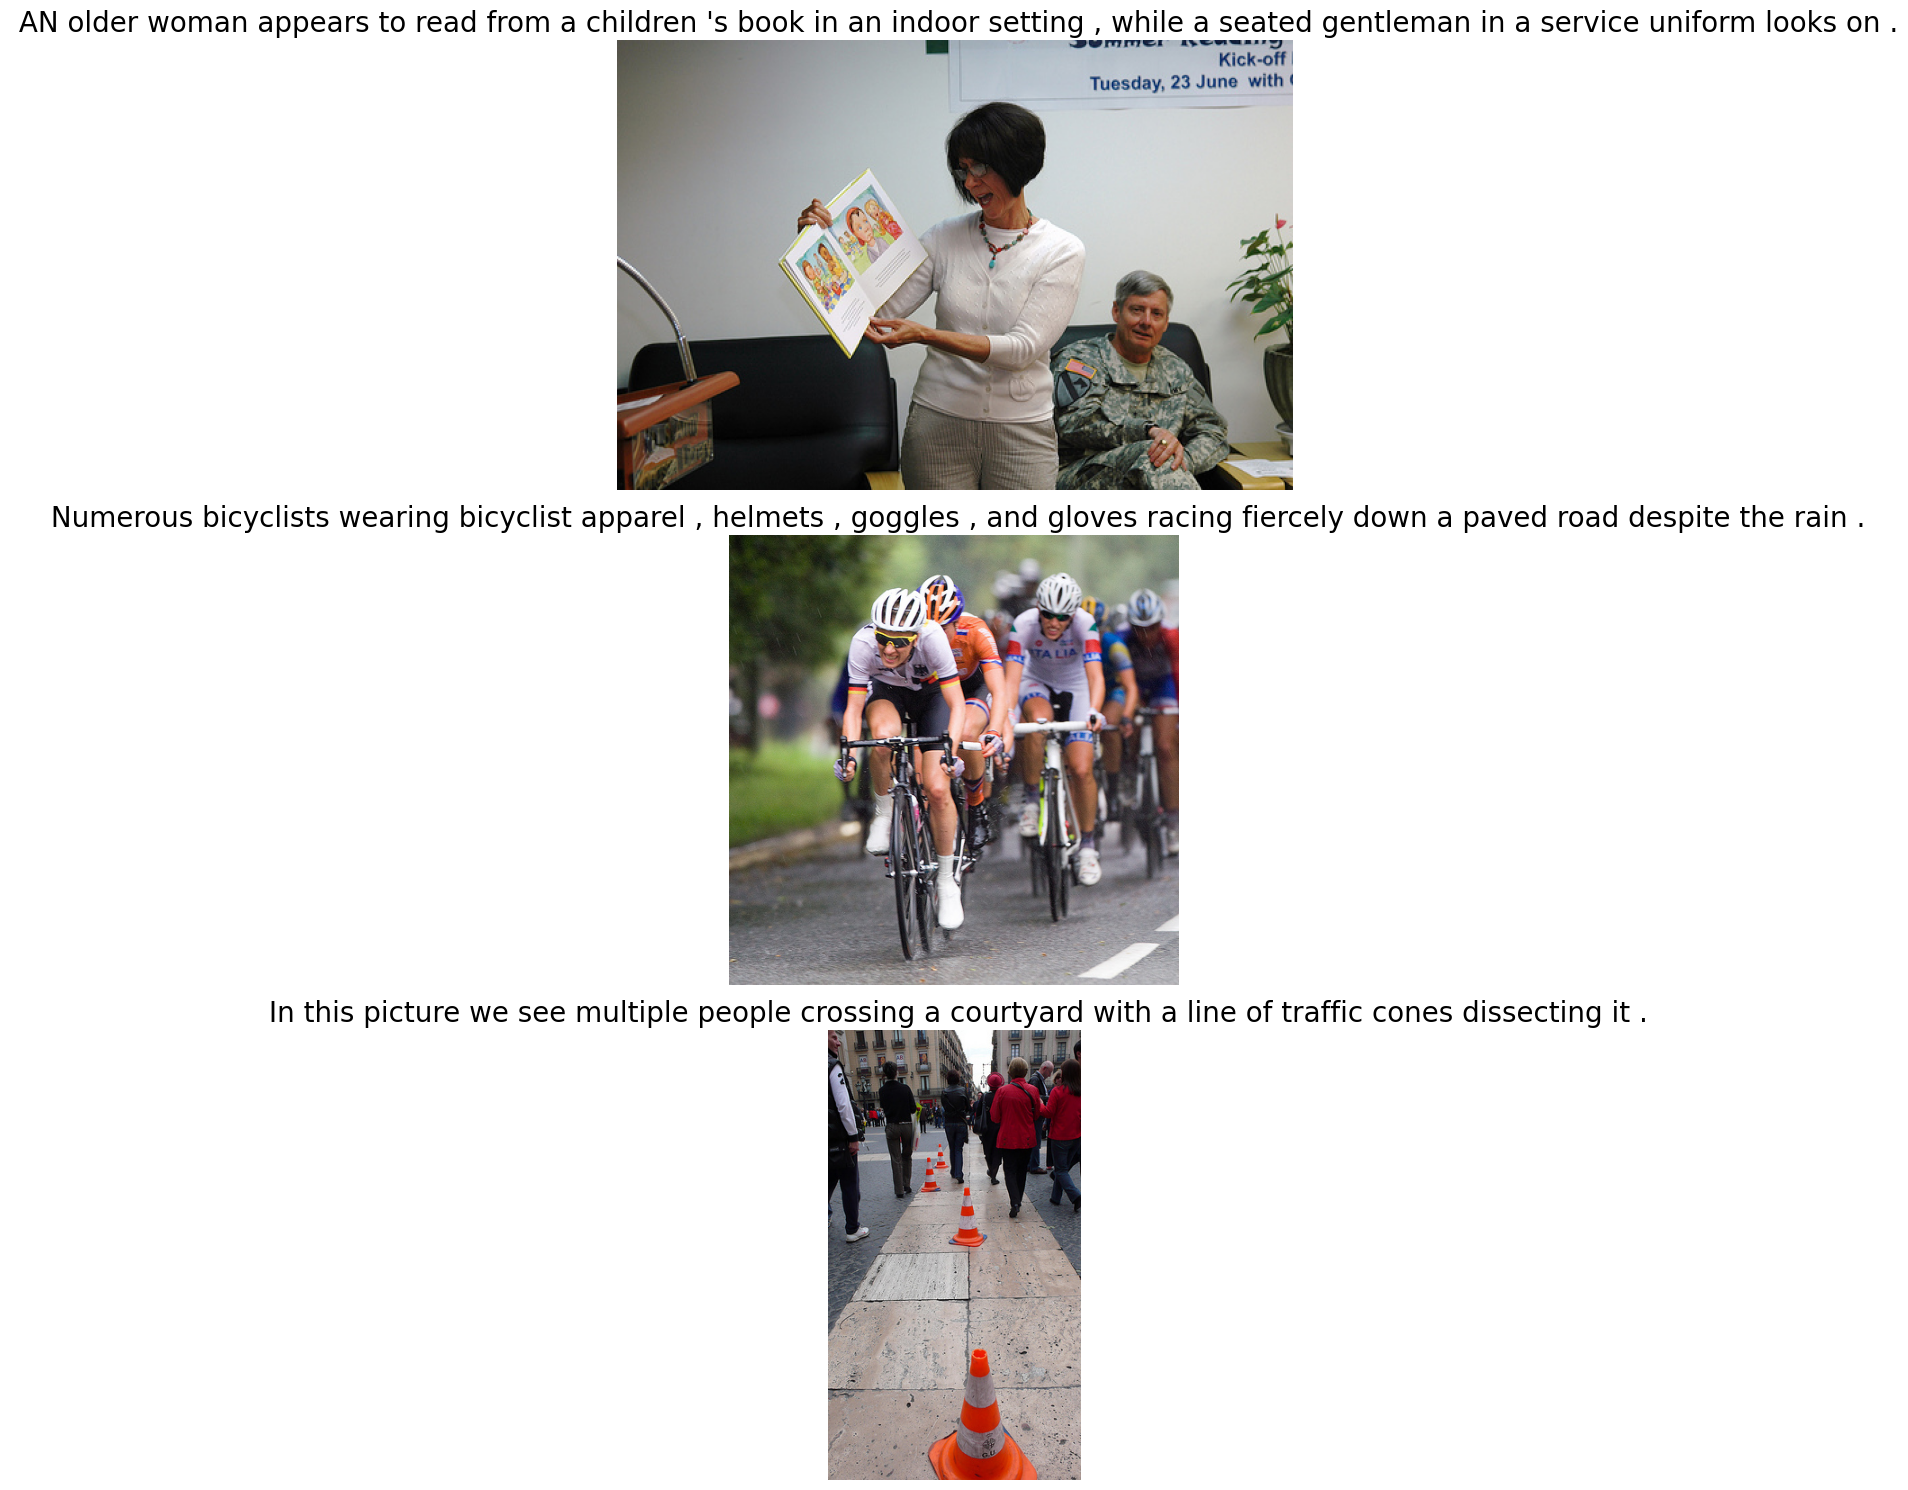

In [18]:
sample_images = df["image"].drop_duplicates().sample(6, random_state=42).tolist()

fig, axes = plt.subplots(3,1,figsize=(15,15))

axes = axes.flatten()

for ax, image_name in zip(axes, sample_images):
    img_path = IMAGES_DIR/ image_name
    img = Image.open(img_path)
    caption = df[df["image"] == image_name]["caption"].iloc[0]

    ax.imshow(img)
    ax.axis("off")
    ax.set_title(caption, fontsize=20)

plt.tight_layout()
plt.show()

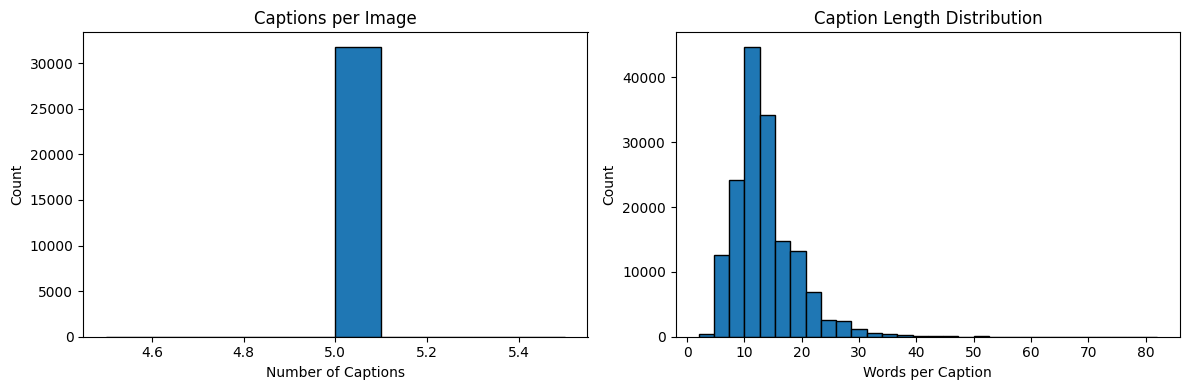

In [19]:
caption_counts = df.groupby("image").size()
caption_lengths = df["caption"].str.split().str.len()

fig, axes = plt.subplots(1,2, figsize=(12, 4))

axes[0].hist(caption_counts, bins=10, edgecolor="black")
axes[0].set_title("Captions per Image")
axes[0].set_xlabel("Number of Captions")
axes[0].set_ylabel("Count")

axes[1].hist(caption_lengths, bins=30, edgecolor="black")
axes[1].set_title("Caption Length Distribution")
axes[1].set_xlabel("Words per Caption")
axes[1].set_ylabel("Count")

plt.tight_layout()

plt.show()

So, On an average Most of the captions are in the range of (10, 30) words

---
## Section 3 — Caption Length Analysis

Understanding the distribution of caption lengths (in words and tokens) is critical because:
- It determines the `max_length` we pass to the tokenizer during preprocessing.
- It shows whether very long or very short captions exist that might need filtering.
- It confirms the quality and consistency of the Flickr30k annotations.

In [20]:
# Add a word-count column to the DataFrame
df['word_count'] = df['caption'].str.strip().str.split().str.len()

print('Caption Length Statistics (in words):')
print(df['word_count'].describe().round(2))

Caption Length Statistics (in words):
count    158914.00
mean         13.39
std           5.42
min           2.00
25%          10.00
50%          12.00
75%          16.00
max          82.00
Name: word_count, dtype: float64


The statistics above reveal:
- **Mean** — the average number of words per caption (expected ~10–12 words for Flickr30k).
- **Max** — the longest caption. This helps us set an upper bound for `max_length`.
- **Min** — the shortest caption. Very short captions may lack descriptive content.

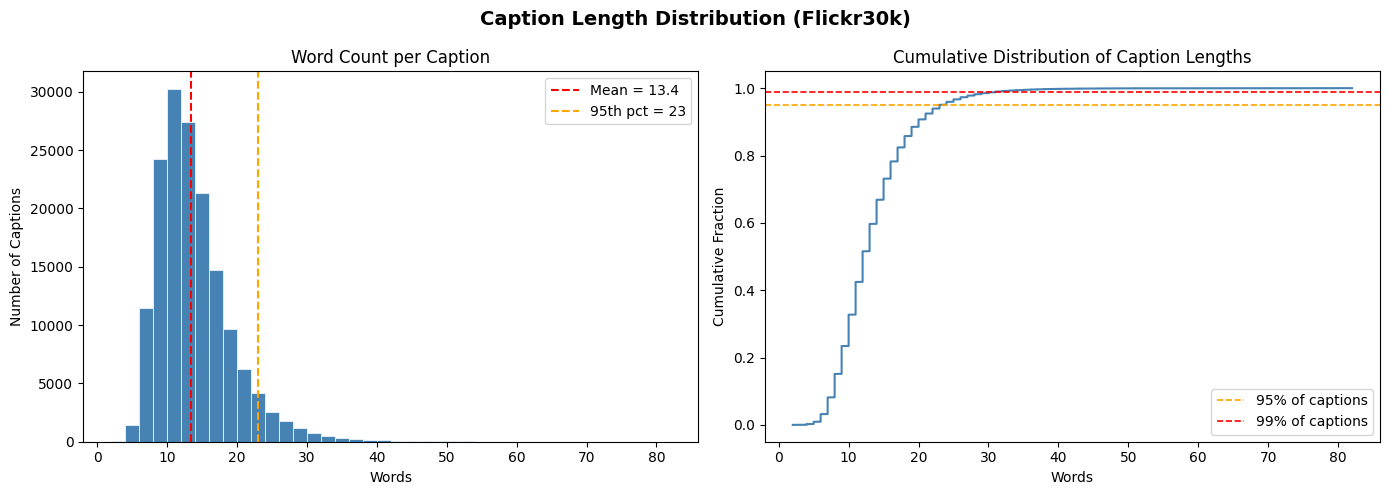

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Caption Length Distribution (Flickr30k)', fontsize=14, fontweight='bold')

# Left plot: histogram of word counts
axes[0].hist(df['word_count'], bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(df['word_count'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean = {df["word_count"].mean():.1f}')
axes[0].axvline(df['word_count'].quantile(0.95), color='orange', linestyle='--', linewidth=1.5, label=f'95th pct = {df["word_count"].quantile(0.95):.0f}')
axes[0].set_title('Word Count per Caption')
axes[0].set_xlabel('Words')
axes[0].set_ylabel('Number of Captions')
axes[0].legend()

# Right plot: cumulative distribution — helps pick max_length cutoff

sorted_lengths = df['word_count'].sort_values()
cumulative = [i / len(sorted_lengths) for i in range(len(sorted_lengths))]
axes[1].plot(sorted_lengths.values, cumulative, color='steelblue')
axes[1].axhline(0.95, color='orange', linestyle='--', linewidth=1.2, label='95% of captions')
axes[1].axhline(0.99, color='red', linestyle='--', linewidth=1.2, label='99% of captions')

axes[1].set_title('Cumulative Distribution of Caption Lengths')
axes[1].set_xlabel('Words')
axes[1].set_ylabel('Cumulative Fraction')
axes[1].legend()

plt.tight_layout()
plt.show()

**Key Takeaway**: The 95th–99th percentile values tell us a safe `max_length` for the tokenizer.
Setting `max_length = 64` tokens should comfortably cover **>99%** of all captions in this dataset without truncation.

---
## Section 4 — Vocabulary Analysis

Analysing the vocabulary helps us understand:
- The total number of unique words (**raw vocabulary size**).
- The most frequent words — do they make sense for captioning (nouns, verbs, adjectives)?
- The proportion of rare words — these will likely remain unseen by the model.

In [24]:
from collections import Counter

# Tokenise all captions into individual words (lowercase)
all_words = df['caption'].str.lower().str.replace(r'[^a-z\s]', '', regex=True).str.split().explode()

word_freq = Counter(all_words.tolist())

print(f'Total tokens (non-unique) : {len(all_words):,}')
print(f'Unique vocabulary size     : {len(word_freq):,}')
print(f'Words appearing only once  : {sum(1 for v in word_freq.values() if v == 1):,}')

Total tokens (non-unique) : 1,946,806
Unique vocabulary size     : 19,771
Words appearing only once  : 7,407


A large vocabulary confirms that using a **pretrained tokenizer** (GPT-2's BPE tokenizer) is the right call.
Training a tokenizer from scratch on ~155k captions would produce a poor vocabulary.
GPT-2's tokenizer already handles all these words effectively through sub-word tokenisation.

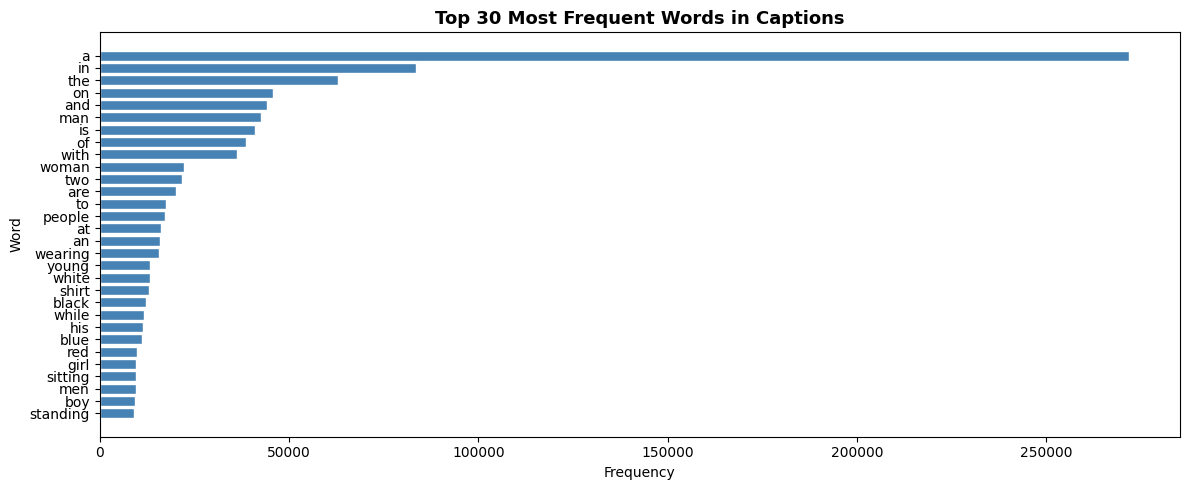


Top 30 words:
    word  frequency
       a     271705
      in      83466
     the      62978
      on      45669
     and      44263
     man      42598
      is      41117
      of      38776
    with      36207
   woman      22211
     two      21642
     are      20196
      to      17607
  people      17337
      at      16259
      an      15883
 wearing      15709
   young      13218
   white      13178
   shirt      12981
   black      12311
   while      11711
     his      11495
    blue      11310
     red       9916
    girl       9655
 sitting       9620
     men       9499
     boy       9429
standing       9113


In [25]:
import pandas as pd

# Top-30 most frequent words
top_words = pd.DataFrame(word_freq.most_common(30), columns=['word', 'frequency'])

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(top_words['word'][::-1], top_words['frequency'][::-1], color='steelblue', edgecolor='white')
ax.set_title('Top 30 Most Frequent Words in Captions', fontsize=13, fontweight='bold')
ax.set_xlabel('Frequency')
ax.set_ylabel('Word')
plt.tight_layout()
plt.show()

print('\nTop 30 words:')
print(top_words.to_string(index=False))

The top words are expected to be common caption words: `a`, `the`, `man`, `woman`, `in`, `on`, `with`, etc.
This confirms the dataset is clean and natural-language-like — exactly what a language model like GPT-2 is designed to handle.

In [26]:
# Frequency distribution: how many words appear exactly 1, 2, 3, ... times?
freq_buckets = Counter(word_freq.values())
bucket_df = pd.DataFrame(sorted(freq_buckets.items())[:20], columns=['occurrences', 'num_words'])

print('Word frequency distribution (first 20 buckets):')
print(bucket_df.to_string(index=False))

rare_words = sum(1 for v in word_freq.values() if v <= 5)
print(f'\nWords appearing 5 or fewer times: {rare_words:,} ({100*rare_words/len(word_freq):.1f}% of vocabulary)')

Word frequency distribution (first 20 buckets):
 occurrences  num_words
           1       7407
           2       2404
           3       1386
           4        889
           5        649
           6        539
           7        413
           8        341
           9        297
          10        297
          11        229
          12        202
          13        181
          14        173
          15        158
          16        132
          17        117
          18        127
          19        115
          20        123

Words appearing 5 or fewer times: 12,735 (64.4% of vocabulary)


Words that appear very rarely (≤ 5 times) represent the long tail of the vocabulary.
Since we use a **pretrained BPE tokenizer**, these rare words are handled via sub-word splitting,
so they do not pose a problem (unlike custom vocabularies that use `<UNK>` tokens for rare words).

---
## Section 5 — Image Dimension Analysis

Before feeding images into ViT, we need to confirm:
- Are all images RGB (3-channel)? ViT requires 3 channels — greyscale images must be converted.
- What are the typical image dimensions? ViT resizes everything to 224×224, but knowing the original dimensions shows how much information is lost or padded.
- Are there unusually small images that may not contain enough visual detail?

In [27]:
from PIL import Image
from pathlib import Path
import random

# Sample 500 images for speed (checking all 31k takes too long)
sample_images = df['image_path'].drop_duplicates().sample(500, random_state=42).tolist()

widths, heights, modes = [], [], []

for img_path in sample_images:
    try:
        with Image.open(img_path) as img:
            widths.append(img.width)
            heights.append(img.height)
            modes.append(img.mode)
    except Exception as e:
        print(f'Error reading {img_path}: {e}')

dim_df = pd.DataFrame({'width': widths, 'height': heights, 'mode': modes})

print('Image Dimension Statistics (sampled 500 images):')
print(dim_df[['width', 'height']].describe().round(0))
print(f'\nImage modes (colour spaces):')
print(dim_df['mode'].value_counts())

Image Dimension Statistics (sampled 500 images):
       width  height
count  500.0   500.0
mean   457.0   397.0
std     71.0    75.0
min    200.0   198.0
25%    389.0   333.0
50%    500.0   375.0
75%    500.0   500.0
max    500.0   500.0

Image modes (colour spaces):
mode
RGB    500
Name: count, dtype: int64


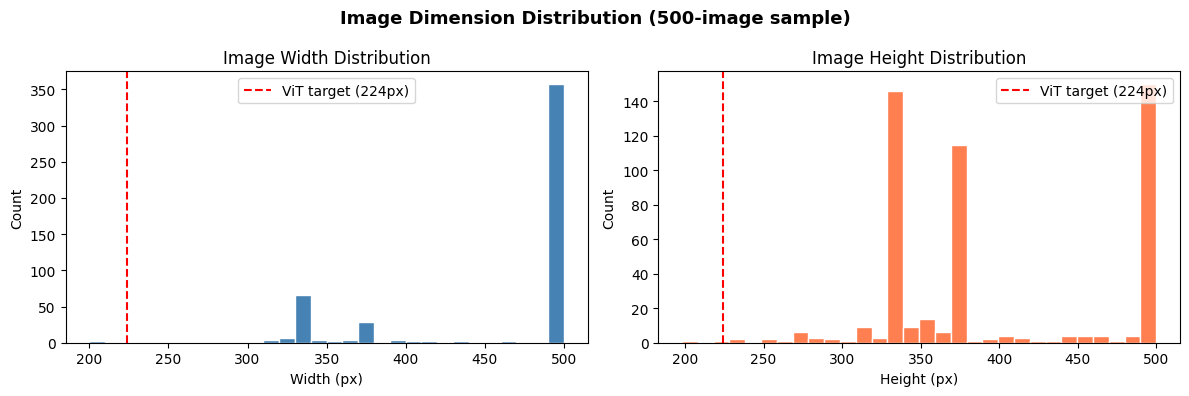

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Image Dimension Distribution (500-image sample)', fontsize=13, fontweight='bold')

axes[0].hist(widths, bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(224, color='red', linestyle='--', linewidth=1.5, label='ViT target (224px)')
axes[0].set_title('Image Width Distribution')
axes[0].set_xlabel('Width (px)')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(heights, bins=30, color='coral', edgecolor='white')
axes[1].axvline(224, color='red', linestyle='--', linewidth=1.5, label='ViT target (224px)')
axes[1].set_title('Image Height Distribution')
axes[1].set_xlabel('Height (px)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

**Key Takeaways:**
- Most images are non-square (different widths and heights), which is normal for Flickr photos.
- `ViTImageProcessor` handles resizing to **224×224** and normalisation automatically — no manual transform code needed.
- If any images are in `L` (greyscale) or `RGBA` mode, they must be converted to `RGB` before processing. The `.convert('RGB')` call in our Dataset class will handle this.

---
## Section 6 — Data Exploration Summary

Before moving to preprocessing, here is a consolidated view of everything we learned:

In [29]:
print('=' * 60)
print('FLICKR30K DATA EXPLORATION SUMMARY')
print('=' * 60)
print(f'Total images            : {df["image"].nunique():,}')
print(f'Total captions          : {len(df):,}')
print(f'Captions per image      : exactly 5 (confirmed)')
print(f'Missing image files     : 0 (all images present)')
print()
print(f'Caption length (words)  : mean={df["word_count"].mean():.1f}  '
      f'std={df["word_count"].std():.1f}  '
      f'max={df["word_count"].max()}')
print(f'99th pct caption length : {df["word_count"].quantile(0.99):.0f} words')
print(f'Recommended max_length  : 64 tokens (covers 99%+ of captions)')
print()
print(f'Unique vocabulary size  : {len(word_freq):,} words')
print(f'Rare words (<=5 times)  : {rare_words:,}')
print(f'Tokenizer strategy      : GPT-2 BPE (pretrained, no UNK problem)')
print()
print(f'Image colour mode       : RGB (confirmed, .convert("RGB") for safety)')
print(f'Image resize target     : 224x224 (via ViTImageProcessor)')
print('=' * 60)
print()
print('NEXT STEP: notebook 02_data_preprocessing.ipynb')
print('  - Setup ViTImageProcessor')
print('  - Setup GPT-2 tokenizer with SOS/EOS/PAD tokens')
print('  - Build Flickr30kDataset class')
print('  - Create train/val/test split (Karpathy: 29000/1014/1000)')
print('  - Build DataLoaders (batch_size=32)')

FLICKR30K DATA EXPLORATION SUMMARY
Total images            : 31,783
Total captions          : 158,915
Captions per image      : exactly 5 (confirmed)
Missing image files     : 0 (all images present)

Caption length (words)  : mean=13.4  std=5.4  max=82.0
99th pct caption length : 32 words
Recommended max_length  : 64 tokens (covers 99%+ of captions)

Unique vocabulary size  : 19,771 words
Rare words (<=5 times)  : 12,735
Tokenizer strategy      : GPT-2 BPE (pretrained, no UNK problem)

Image colour mode       : RGB (confirmed, .convert("RGB") for safety)
Image resize target     : 224x224 (via ViTImageProcessor)

NEXT STEP: notebook 02_data_preprocessing.ipynb
  - Setup ViTImageProcessor
  - Setup GPT-2 tokenizer with SOS/EOS/PAD tokens
  - Build Flickr30kDataset class
  - Create train/val/test split (Karpathy: 29000/1014/1000)
  - Build DataLoaders (batch_size=32)


 Data Exploration Complete

 The dataset is clean, complete, and well-structured.
 All preprocessing decisions (max_length=64, RGB conversion, 224×224 resize, GPT-2 tokenizer)
 are backed by the analysis above. Proceed to 02_data_preprocessing.ipynb.